**Install the required libraries**

In [ ]:
# Install libraries to use matminer.
# ⚠️ After running this once, please click the button runtime and restart the session/kernel
# and run the code again from a fresh session.
# Ignore the Error Message
!pip uninstall -y opencv-python opencv-contrib-python opencv-python-headless thinc -q
!pip install opencv-python==4.10.0.84 opencv-contrib-python==4.10.0.84 -q
!pip install thinc==8.1.12 -q
!pip install numpy==1.26.4 pandas==2.2.2 matplotlib==3.8.0 -q
!pip install pyyaml six -q
!pip install matminer pymatgen -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for thinc (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for thinc
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (thinc)
fatal: destination path 'MS697-material' already exists and is not an empty directory.


# **1. Train and Test ML algorithm: Boston house price case**

**Loading libraries we want to use in this notebook**

(you don't need to load all of libraries at first and you can load it anytime and anywhere)

In [ ]:
import pandas as pd # a software library written for the Python programming language for data manipulation and analysis. In particular, it offers data structures and operations for manipulating numerical tables and time series
import seaborn as sns # Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import numpy as np # a software library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays.
import matplotlib.pyplot as plt # a plotting library for the Python programming language

# sklearn is a machine learning software library for the Python programming language. It features various classification, regression and clustering algorithms including support vector machines, random forests, gradient boosting,
# k-means and DBSCAN, and is designed to interoperate with the Python numerical and scientific libraries NumPy and SciPy.
from sklearn.datasets import fetch_california_housing
from sklearn import linear_model, metrics, model_selection
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression

Loading the boston house-prices dataset from the sklearn repository

In [ ]:
# Load the California housing dataset
california = fetch_california_housing()

In [ ]:
# Print the key values of data
print(california.keys())
# Print the total row and column length of the dataset
print(california.data.shape)
# Print feature names
print(california.feature_names)

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])
(20640, 8)
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


Check the description of dataset

In [ ]:
# Check the description of dataset
print(california.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [ ]:
df = pd.DataFrame(california.data)
df.head()

,0,1,2,3,4,5,6,7
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
# Enter feature as the column name
df.columns = california.feature_names
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
# Put the targetP('Price') in the dataset
df['Price'] = california.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


**Feature selection**

Sometimes, the input variables may not be directly related to the interested target. Hence, a feature selection step is necessary. There are many different methods for selecting features. Here we will go over a simple implementation in scikit-learn.

In [ ]:
# Function that returns feature names
def identify_columns(x_new, nrows=10):
    columns = x_data.columns
    xvalues = x_data.values
    dist = np.linalg.norm(xvalues[:nrows, :, None] - x_new[:nrows, None, :], axis=0)
    return columns[np.argmin(dist, axis=0)].values

In [ ]:
# # x_data contains the features('california.feature_names')
x_data = df[california.feature_names]

# y_data contains the target variable('Price')
y_data = df['Price']

In [ ]:
# Select the top 5 features by using 'SelectKBest'
sel = SelectKBest(f_regression, k=5)
x_new = sel.fit_transform(x_data, y_data)
print(f"Selected features {identify_columns(x_new)}")

Selected features ['MedInc' 'HouseAge' 'AveRooms' 'AveBedrms' 'Latitude']


**1. Train ML algorithm**

/tmp/ipython-input-627178512.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.text(20, 4, "Price = {:.3f} * AveRooms + {:.3f}".format(float(a), float(b)) , fontsize=15, color = "r")


Text(20, 4, 'Price = 0.071 * AveRooms + 1.684')

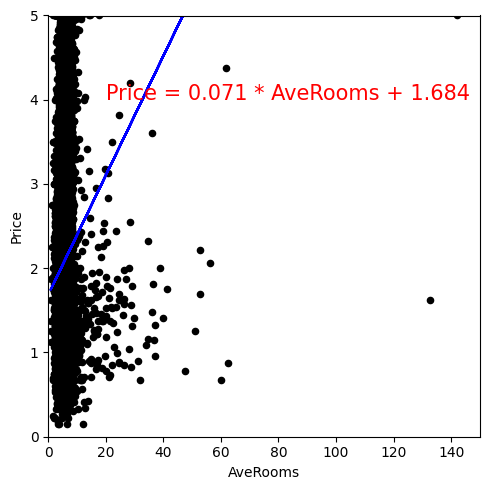

In [ ]:
# Train about the average number of rooms and house prices by using 'LinearRegression'
linear_regression = linear_model.LinearRegression()
linear_regression.fit(X=pd.DataFrame(df['AveRooms']), y=df['Price'])
prediction = linear_regression.predict(X=pd.DataFrame(df['AveRooms']))

# Get the slope and intercept from the trained linear regression model
a = linear_regression.coef_
b = linear_regression.intercept_
df.plot(kind='scatter', x ="AveRooms", y="Price", figsize=(5, 5), color='black', xlim=(0,150), ylim=(0,5))
plt.tight_layout()
plt.plot(df['AveRooms'], prediction, color='b')
plt.text(20, 4, "Price = {:.3f} * AveRooms + {:.3f}".format(float(a), float(b)) , fontsize=15, color = "r")

**2. Train & Test ML algorithm**



In [ ]:
# Classify into training dataset and testing dataset using only "AveRooms" feature
x_data = df[['AveRooms']]
y_data = df['Price']

# Split the data into training and test sets('train_test_split')
x_train, x_test, y_train, y_test = model_selection.train_test_split(x_data, y_data, test_size=0.1)
print("Size of training set: {}, test set: {}".format(len(x_train), len(x_test)))

Size of training set: 18576, test set: 2064


score: 0.02
Mean Squared Error: 1.23
RMSE (* 1000$): 1.11


(0.0, 10.0)

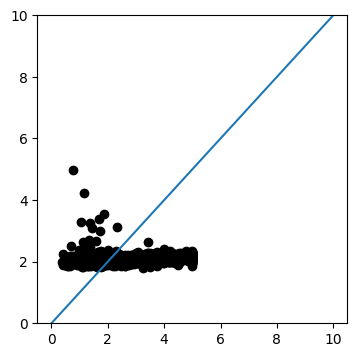

In [ ]:
# Train Linear regression model('fit')
estimator = linear_model.LinearRegression()
estimator.fit(X=x_train, y=y_train)

# Test with prediction by using R2 score('metrics.r2_score')
y_predict_test = estimator.predict(x_test)
score = metrics.r2_score(y_test, y_predict_test)

print('score: {:.2f}'.format(float(score)))
print('Mean Squared Error: {:.2f}'.format(metrics.mean_squared_error(y_predict_test, y_test)))
print('RMSE (* 1000$): {:.2f}'.format(metrics.mean_squared_error(y_predict_test, y_test)**.5))

# Print prediction values about test set
plt.figure(figsize=(4,4))
plt.scatter(y_test, y_predict_test, color='k')
plt.plot([0,10],[0,10])
plt.ylim(0, 10)
plt.ylim(0, 10)

score: 0.64
Mean Squared Error: 0.49
RMSE (* 1000$): 0.70


(0.0, 10.0)

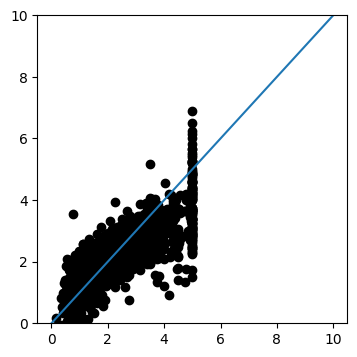

In [ ]:
# Train with all features('california.feature_names')
x_data = df[california.feature_names]
y_data = df['Price']
x_train, x_test, y_train, y_test = model_selection.train_test_split(x_data, y_data, test_size=0.1)

estimator = linear_model.LinearRegression()
estimator.fit(x_train, y_train)

#y_predict_train = estimator.predict(x_train)
#score = metrics.r2_score(y_train, y_predict_train)
#print(score) #1.0

y_predict_test = estimator.predict(x_test)
score = metrics.r2_score(y_test, y_predict_test)

print('score: {:.2f}'.format(float(score)))
print('Mean Squared Error: {:.2f}'.format(metrics.mean_squared_error(y_predict_test, y_test)))
print('RMSE (* 1000$): {:.2f}'.format(metrics.mean_squared_error(y_predict_test, y_test)**.5))

plt.figure(figsize=(4,4))
plt.scatter(y_test, y_predict_test, color='k')
plt.plot([0,10],[0,10])
plt.ylim(0, 10)
plt.ylim(0, 10)

Benchmark the optimial number of features

Selected 1 features Index(['MedInc'], dtype='object')
Selected 2 features Index(['MedInc', 'AveRooms'], dtype='object')
Selected 3 features Index(['MedInc', 'AveRooms', 'Latitude'], dtype='object')
Selected 4 features Index(['MedInc', 'HouseAge', 'AveRooms', 'Latitude'], dtype='object')
Selected 5 features Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Latitude'], dtype='object')
Selected 6 features Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Latitude', 'Longitude'], dtype='object')
Selected 7 features Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'Latitude',
       'Longitude'],
      dtype='object')
Selected 8 features Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')


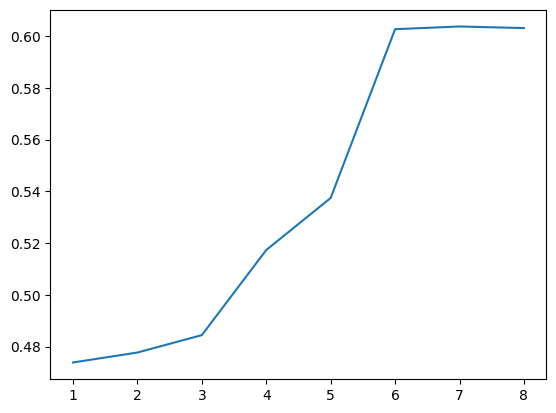

In [ ]:
# Searching the optimal number of features by predicting R2 score while increasing the number of features
all = []
for i in range(1,len(california.feature_names)+1):
  sum_score = 0
  sum_mse = 0
  sum_rmse = 0
  x_data = df[california.feature_names]
  y_data = df['Price']
  sel = SelectKBest(f_regression, k=i)
  x_new = sel.fit_transform(x_data, y_data)
  selected = x_data.columns[sel.get_support()]
  print(f"Selected {i} features {selected}")
  x_data = df[selected]
  y_data = df['Price']
  # To consider changes of R2 score depending on random train set data due to the small number of data,
  # evaluate with the average of R2 score from 1000 iterations of training about the each number of features
  for j in range(1001):
    x_train, x_test, y_train, y_test = model_selection.train_test_split(x_data, y_data, test_size=0.1)
    estimator = linear_model.LinearRegression()
    estimator.fit(x_train, y_train)
    y_predict_test = estimator.predict(x_test)
    sum_score += float(metrics.r2_score(y_test, y_predict_test))
    sum_mse += float(metrics.mean_squared_error(y_predict_test, y_test))
    sum_rmse += float(metrics.mean_squared_error(y_predict_test, y_test)**.5)
 # print('average of score: {:.2f}'.format(sum_score/1000))
 # print('average of Mean Squared Error: {:.2f}'.format(sum_mse/1000))
 # print('average of RMSE (* 1000$): {:.2f}'.format(sum_rmse/1000))
  all.append(sum_score/1000)
plt.plot([i for i in range(1, len(all)+1)], all)

**Benchmark the score (R2) with other various regression ML algorithm (LASSO, Ridge, Random Forest Tree)**

R2 score—varies between 0 and 100%. It is closely related to the mean square error, but not the same. R2 is the proportion of the variance in the dependent variable that is predictable from the independent variable(s). Another definition is “(total variance explained by model) / total variance.” So if it is 100%, the two variables are perfectly correlated, i.e., with no variance at all. A low value would show a low level of correlation, meaning a regression model that is not valid , but not in all cases.

Selected 1 features Index(['MedInc'], dtype='object')
average of score: 44.79
average of Mean Squared Error: 73.66
average of RMSE (* 1000$): 85.85
Selected 2 features Index(['MedInc', 'AveRooms'], dtype='object')
average of score: 44.78
average of Mean Squared Error: 73.68
average of RMSE (* 1000$): 85.86
Selected 3 features Index(['MedInc', 'AveRooms', 'Latitude'], dtype='object')
average of score: 44.73
average of Mean Squared Error: 73.65
average of RMSE (* 1000$): 85.85
Selected 4 features Index(['MedInc', 'HouseAge', 'AveRooms', 'Latitude'], dtype='object')
average of score: 48.18
average of Mean Squared Error: 69.16
average of RMSE (* 1000$): 83.18
Selected 5 features Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Latitude'], dtype='object')
average of score: 48.14
average of Mean Squared Error: 69.06
average of RMSE (* 1000$): 83.13
Selected 6 features Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Latitude', 'Longitude'], dtype='object')
average of score: 48.17

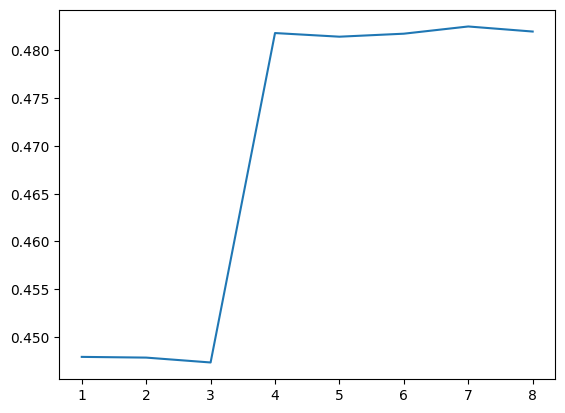

In [ ]:
all = []
for i in range(1,len(california.feature_names)+1):
  sum_score = 0
  sum_mse = 0
  sum_rmse = 0
  x_data = df[california.feature_names]
  y_data = df['Price']
  sel = SelectKBest(f_regression, k=i)
  x_new = sel.fit_transform(x_data, y_data)
  selected = x_data.columns[sel.get_support()]
  print(f"Selected {i} features {selected}")
  x_data = df[selected]
  y_data = df['Price']
  for j in range(1001):
    x_train, x_test, y_train, y_test = model_selection.train_test_split(x_data, y_data, test_size=0.1)

    # For 'Lasso' regression
    estimator = linear_model.Lasso(alpha=0.35, max_iter=1000, tol=0.0001)
    # estimator = linear_model.Ridge(alpha=1)  # For Ridge regression
    # estimator = RandomForestRegressor()  # For Random forest regressor

    estimator.fit(x_train, y_train)
    y_predict_test = estimator.predict(x_test)
    sum_score += float(metrics.r2_score(y_test, y_predict_test))
    sum_mse += float(metrics.mean_squared_error(y_predict_test, y_test))
    sum_rmse += float(metrics.mean_squared_error(y_predict_test, y_test)**.5)
  print('average of score: {:.2f}'.format(sum_score/10))
  print('average of Mean Squared Error: {:.2f}'.format(sum_mse/10))
  print('average of RMSE (* 1000$): {:.2f}'.format(sum_rmse/10))
  all.append(sum_score/1000)
plt.plot([i for i in range(1, len(all)+1)], all)